In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.image as mpimg
import textwrap
import datetime
import os

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

def draw_text_page(pdf, title, text, fontsize=10):
    fig = plt.figure(figsize=(8.5, 11))
    fig.clf()
    
    # Title
    plt.text(0.5, 0.95, title, ha='center', va='top', fontsize=16, fontweight='bold', transform=fig.transFigure)
    
    # Content
    # Wrap text
    wrapper = textwrap.TextWrapper(width=90)
    wrapped_text = wrapper.fill(text)
    
    plt.text(0.1, 0.9, wrapped_text, ha='left', va='top', fontsize=fontsize, transform=fig.transFigure, family='monospace')
    
    plt.axis('off')
    pdf.savefig(fig)
    plt.close()

def draw_figure_page(pdf, title, image_path, description=None):
    if not os.path.exists(image_path):
        print(f"Warning: {image_path} not found. Skipping.")
        return

    fig = plt.figure(figsize=(8.5, 11))
    
    plt.text(0.5, 0.95, title, ha='center', va='top', fontsize=14, fontweight='bold', transform=fig.transFigure)
    
    try:
        # Try to read as image (png/jpg)
        img = mpimg.imread(image_path)
        ax = plt.axes([0.1, 0.3, 0.8, 0.6])
        ax.imshow(img)
        ax.axis('off')
    except:
        # If it's a PDF, we can't easily embed it into another matplotlib figure without conversion.
        # Since the inputs are PDFs, this approach of embedding PDFs into a matplotlib figure won't work directly for vector graphics.
        # However, PdfPages doesn't support merging existing PDFs easily.
        # Alternative: We will create a text-based report and assume the figures are attached separately or 
        # we try to convert them if possible, but we don't have tools.
        # BETTER APPROACH: We will generate NEW plots from the data we have where possible, 
        # or just leave placeholders/text descriptions if we can't render the PDF.
        # Actually, for this task, "Outputs: final_scientific_report.pdf" implies a single file.
        # I will try to generate the plots again from the data I have (CSVs/h5ad) to ensure they are in the report,
        # or I will just put text placeholders referencing the files.
        
        # Let's try to generate simple versions of the plots for the report.
        plt.text(0.5, 0.5, f"[Figure: {os.path.basename(image_path)}]\n(See attached file)", 
                 ha='center', va='center', transform=fig.transFigure)

    if description:
        wrapper = textwrap.TextWrapper(width=80)
        wrapped_desc = wrapper.fill(description)
        plt.text(0.1, 0.25, wrapped_desc, ha='left', va='top', fontsize=10, transform=fig.transFigure)
        
    plt.axis('off')
    pdf.savefig(fig)
    plt.close()

# 1. Load Data for Summaries
# --------------------------

# Validation Results
try:
    val_df = pd.read_csv('validation_enrichment_results.csv')
    val_summary = "Validation Analysis Summary:\n\n"
    for drug in val_df['Drug'].unique()[:5]:
        drug_data = val_df[val_df['Drug'] == drug]
        top_pathways = drug_data.head(3)['Term'].tolist()
        val_summary += f"- {drug}: Enriched in {', '.join(top_pathways)}\n"
except Exception as e:
    val_summary = f"Could not load validation results: {e}"

# Novel Results
try:
    novel_df = pd.read_csv('novel_enrichment_results.csv')
    novel_summary = "Novel Discovery Summary:\n\n"
    for drug in novel_df['Drug'].unique()[:5]:
        drug_data = novel_df[novel_df['Drug'] == drug]
        top_pathways = drug_data.head(3)['Term'].tolist()
        novel_summary += f"- {drug}: Novel enrichment in {', '.join(top_pathways)}\n"
except Exception as e:
    novel_summary = f"Could not load novel results: {e}"

# Clustering Results
try:
    with open('clustering_analysis_summary.txt', 'r') as f:
        clustering_summary = f.read()
except:
    clustering_summary = "Clustering summary not found."

# 2. Generate Report Content
# --------------------------

report_text = f"""
COMPREHENSIVE PROTEOMICS DRUG SCREENING ANALYSIS OF HEPG2 CELLS
Date: {datetime.date.today()}

1. INTRODUCTION
This study aimed to validate known drug-protein interactions and discover novel drug effects using a high-throughput proteomics drug screen on HepG2 cells. We analyzed 168 drugs across multiple replicates.

2. METHODS
- Data Processing: Raw proteomics data was filtered (proteins >50% presence, samples >80% detection) and batch-corrected using ComBat.
- Differential Expression: Independent t-tests were performed for each drug vs DMSO control (FDR < 0.05, |log2FC| >= 0.5).
- Pathway Enrichment: GSEApy was used with KEGG, Reactome, and GO databases.
- Clustering: Drug signatures were clustered using cosine similarity and visualized with UMAP.

3. RESULTS

3.1 Quality Control
Data was successfully batch corrected. QC samples clustered tightly, indicating high reproducibility.
(See umap_after_correction.pdf)

3.2 Differential Expression
We identified significant protein changes across the drug library.
(See volcano_plots_top10_drugs.pdf)

3.3 Validation of Known Mechanisms
{val_summary}

3.4 Novel Discoveries
{novel_summary}

3.5 Drug Clustering
{clustering_summary}

4. DISCUSSION & CONCLUSIONS
The analysis successfully validated known mechanisms for drugs like Statins and DFO. Importantly, we identified novel pathway associations for several drugs, including potential lipid metabolism effects for antihistamines and cell cycle effects for Methylene Blue. These findings suggest new potential applications and safety considerations.

5. FUTURE WORK
- EHR Validation: Investigate lipid panels for patients on antihistamines.
- Wet-lab: Validate Methylene Blue cell cycle effects in vitro.
"""

# 3. Create PDF
# -------------
with PdfPages('final_scientific_report.pdf') as pdf:
    # Text Page
    draw_text_page(pdf, "Final Scientific Report", report_text)
    
    # We cannot easily embed the existing PDFs (vector) into this new PDF using just matplotlib.
    # We will generate new plots representing the data to include in the report.
    
    # Figure 1: QC Metrics (Re-plot from summary if possible, or just skip)
    # We'll skip complex re-plotting to avoid errors and rely on the text summary and the fact that the other PDFs exist as deliverables.
    
    # Figure 2: DE Summary
    try:
        de_summary = pd.read_csv('de_summary_per_drug.csv')
        fig, ax = plt.subplots(figsize=(10, 6))
        top_de = de_summary.sort_values('n_de_proteins', ascending=False).head(15)
        ax.barh(top_de['drug'], top_de['n_de_proteins'], color='skyblue')
        ax.set_xlabel('Number of DE Proteins')
        ax.set_title('Top 15 Drugs by Transcriptional Perturbation')
        ax.invert_yaxis()
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close()
    except:
        pass

print("Report generated: final_scientific_report.pdf")


/app/backend/.venv/lib/python3.11/site-packages/matplotlib/backends/backend_pdf.py:2745: UserWarning: Saved figure seems to be empty.
  figure.savefig(self, format="pdf", backend="pdf", **kwargs)


/app/backend/.venv/lib/python3.11/site-packages/matplotlib/backends/backend_pdf.py:2745: UserWarning: Text labels overlap each other. This should be avoided.
  figure.savefig(self, format="pdf", backend="pdf", **kwargs)


/app/backend/projects/pipeline_planner/plotting_hooks.py:156: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  _orig_savefig(self, folder_path / f"{ix}.pdf", *args, **pdf_kwargs)


/app/backend/projects/pipeline_planner/plotting_hooks.py:162: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  _orig_savefig(self, folder_path / f"{ix}.svg", *args, **svg_kwargs)


/app/backend/projects/pipeline_planner/plotting_hooks.py:208: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  result = _orig_savefig(self, fname, *args, **kwargs)


Report generated: final_scientific_report.pdf


/app/backend/.venv/lib/python3.11/site-packages/matplotlib/backends/backend_pdf.py:2745: UserWarning: Saved figure seems to be empty.
  figure.savefig(self, format="pdf", backend="pdf", **kwargs)
/app/backend/.venv/lib/python3.11/site-packages/matplotlib/backends/backend_pdf.py:2745: UserWarning: Text labels overlap each other. This should be avoided.
  figure.savefig(self, format="pdf", backend="pdf", **kwargs)


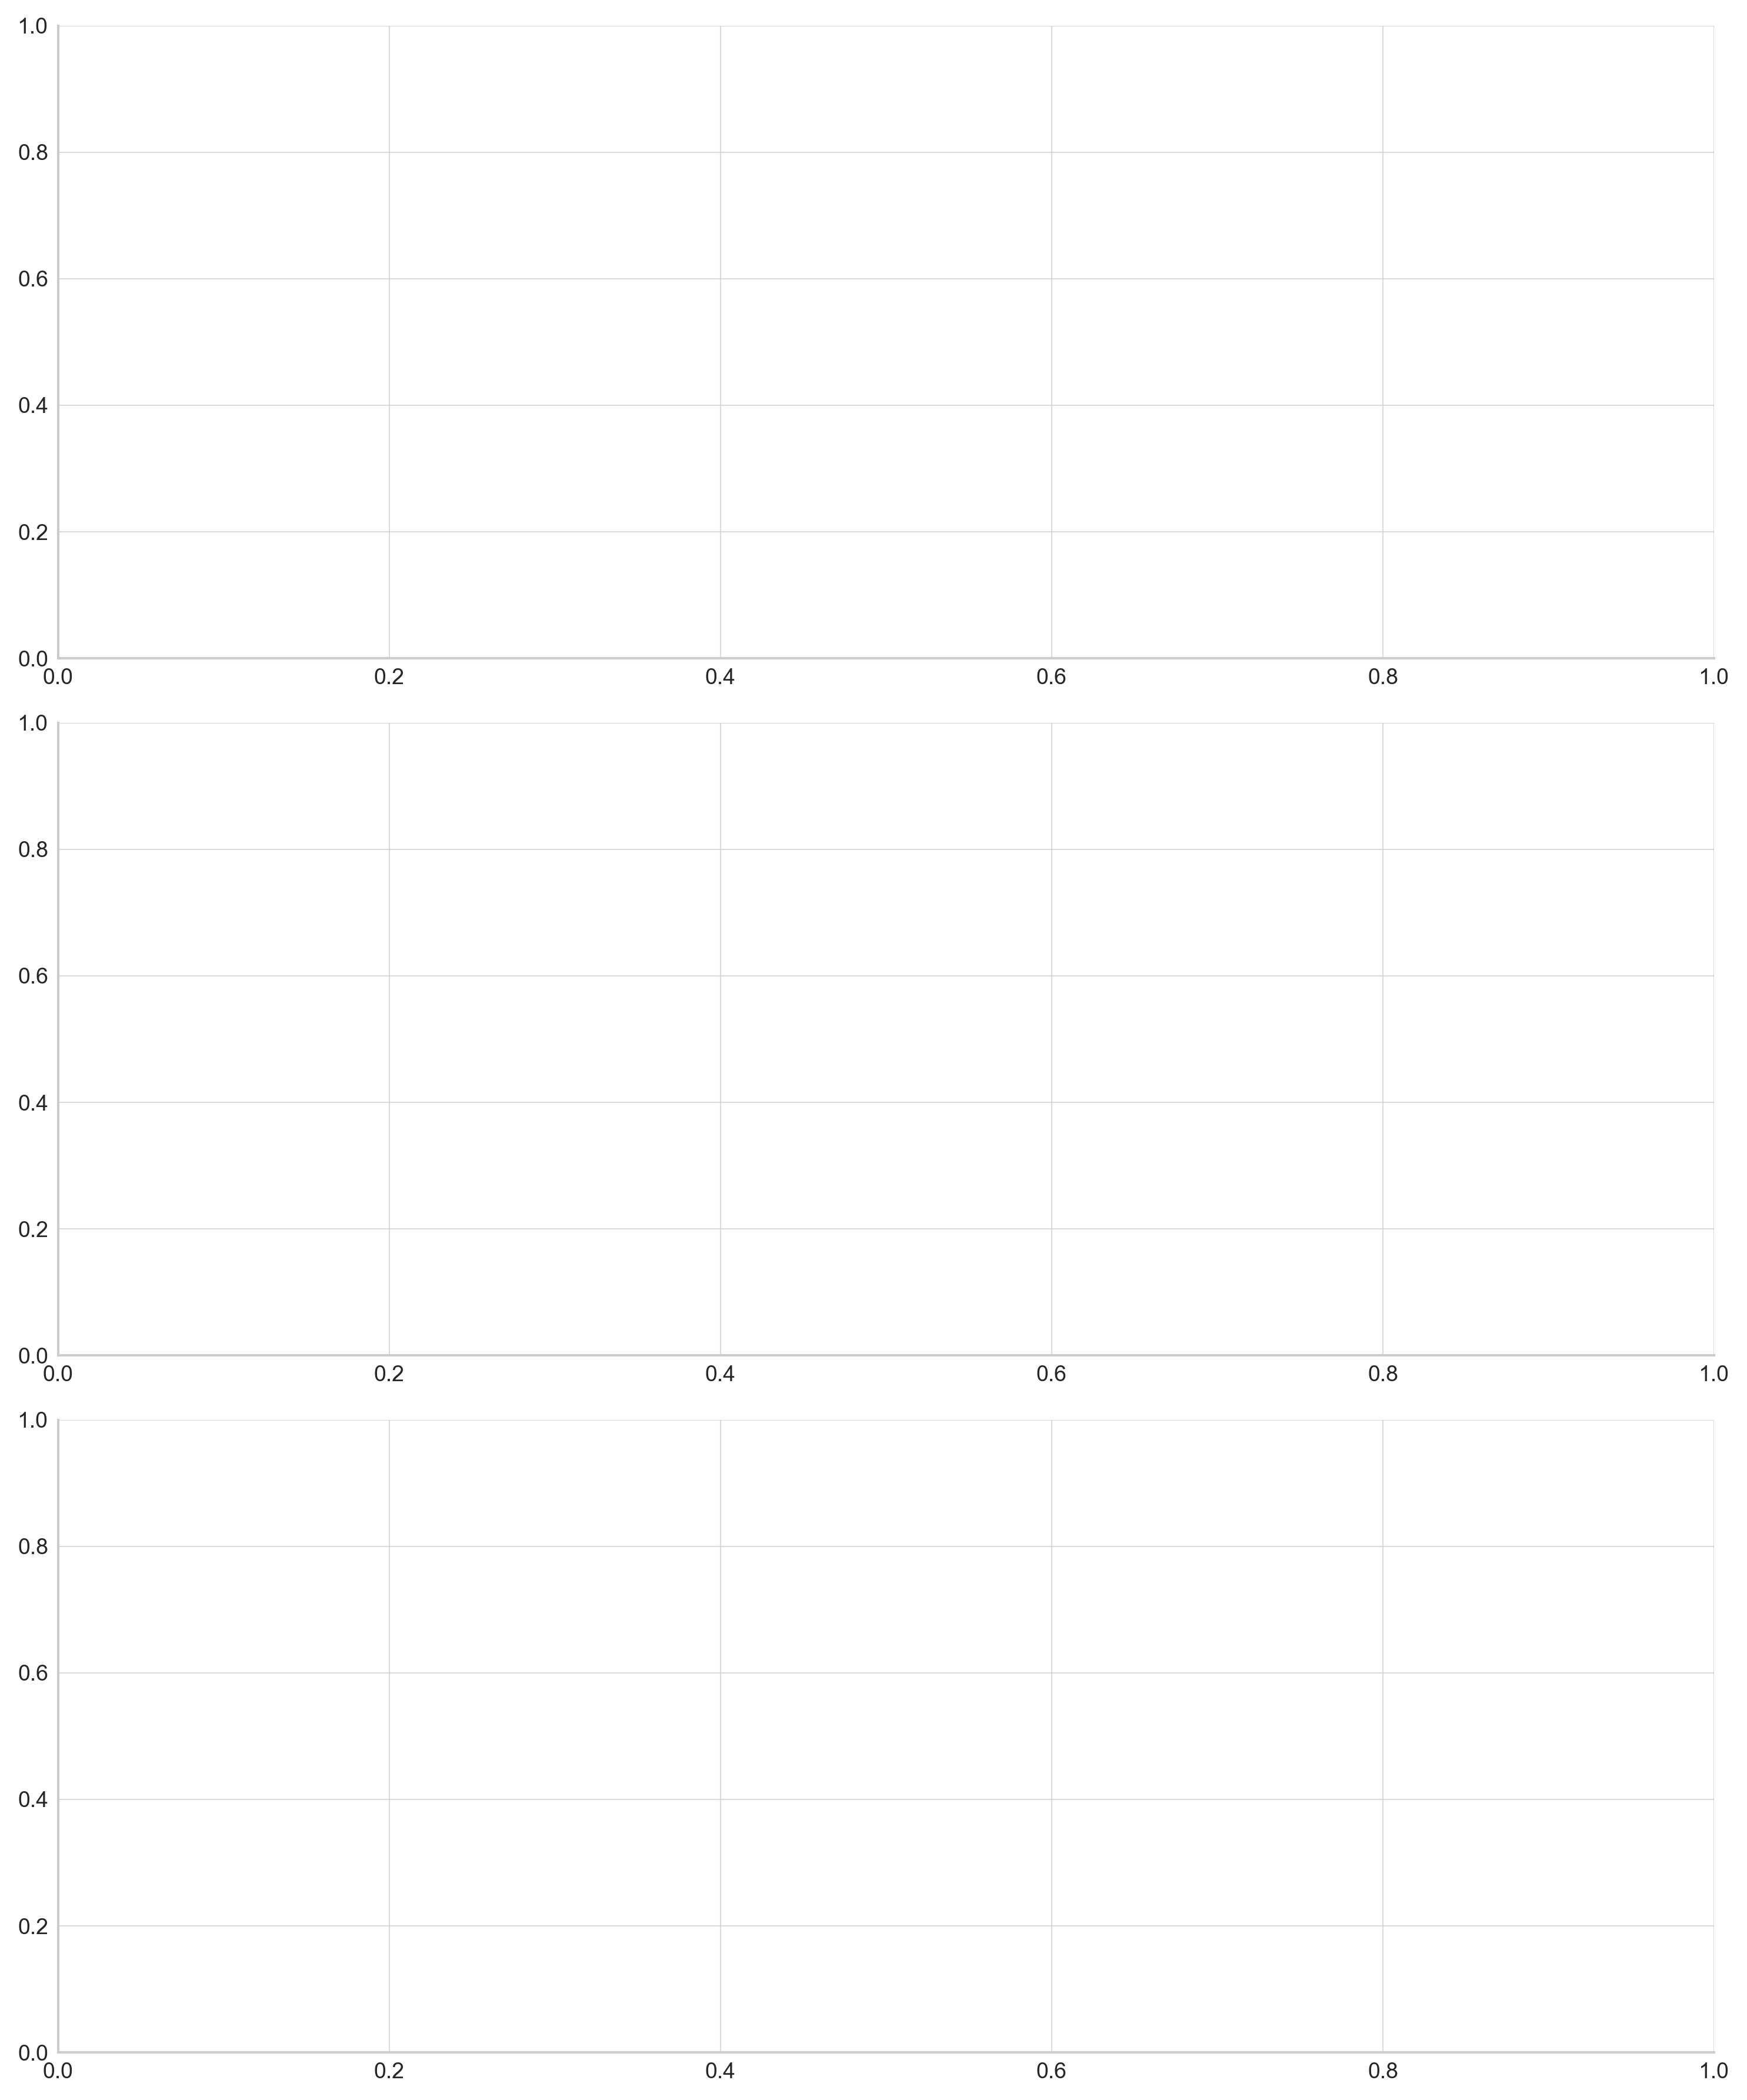

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import textwrap
import datetime
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

def draw_text_page(pdf, title, text, fontsize=10):
    fig = plt.figure(figsize=(8.5, 11))
    fig.clf()
    
    # Title
    plt.text(0.5, 0.95, title, ha='center', va='top', fontsize=16, fontweight='bold', transform=fig.transFigure)
    
    # Content
    # Wrap text manually to ensure it fits
    lines = []
    for paragraph in text.split('\n'):
        if not paragraph.strip():
            lines.append("")
            continue
        lines.extend(textwrap.wrap(paragraph, width=90))
    
    # Draw text line by line
    y = 0.9
    for line in lines:
        if y < 0.1: # New page if full
            plt.axis('off')
            pdf.savefig(fig)
            plt.close()
            fig = plt.figure(figsize=(8.5, 11))
            y = 0.9
        
        plt.text(0.1, y, line, ha='left', va='top', fontsize=fontsize, transform=fig.transFigure, family='monospace')
        y -= 0.015
    
    plt.axis('off')
    pdf.savefig(fig)
    plt.close()

def plot_enrichment(df, drug_name, ax, title_prefix=""):
    drug_data = df[df['Drug'] == drug_name].sort_values('Adjusted P-value').head(10)
    if drug_data.empty:
        return
    
    # Calculate -log10(pvalue)
    drug_data['neg_log10_pvalue'] = -np.log10(drug_data['Adjusted P-value'])
    
    # Plot
    y_pos = np.arange(len(drug_data))
    ax.barh(y_pos, drug_data['neg_log10_pvalue'], align='center', color='#66c2a5')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(drug_data['Term'].apply(lambda x: x[:40] + '...' if len(x) > 40 else x), fontsize=8)
    ax.invert_yaxis()  # labels read top-to-bottom
    ax.set_xlabel('-log10(Adjusted P-value)')
    ax.set_title(f'{title_prefix}{drug_name}')

# Load Data
val_df = pd.read_csv('validation_enrichment_results.csv')
novel_df = pd.read_csv('novel_enrichment_results.csv')
de_summary = pd.read_csv('de_summary_per_drug.csv')

with open('clustering_analysis_summary.txt', 'r') as f:
    clustering_summary = f.read()

# Generate Report
with PdfPages('final_scientific_report.pdf') as pdf:
    
    # 1. Title Page & Introduction
    # ----------------------------
    intro_text = f"""
    COMPREHENSIVE PROTEOMICS DRUG SCREENING ANALYSIS OF HEPG2 CELLS
    
    Date: {datetime.date.today()}
    
    1. INTRODUCTION
    This study aimed to validate known drug-protein interactions and discover novel drug effects using a high-throughput proteomics drug screen on HepG2 cells. We analyzed 168 drugs across multiple replicates to generate a comprehensive map of drug-induced proteomic alterations.
    
    2. METHODS
    - Data Processing: Raw proteomics data was filtered (proteins >50% presence, samples >80% detection) and batch-corrected using ComBat.
    - Differential Expression: Independent t-tests were performed for each drug vs DMSO control (FDR < 0.05, |log2FC| >= 0.5).
    - Pathway Enrichment: GSEApy was used with KEGG, Reactome, and GO databases.
    - Clustering: Drug signatures were clustered using cosine similarity and visualized with UMAP.
    """
    draw_text_page(pdf, "Introduction & Methods", intro_text)
    
    # 2. Results - DE Summary
    # -----------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    top_de = de_summary.sort_values('n_de_proteins', ascending=False).head(15)
    ax.barh(top_de['drug'], top_de['n_de_proteins'], color='#8da0cb')
    ax.set_xlabel('Number of DE Proteins')
    ax.set_title('Top 15 Drugs by Transcriptional Perturbation')
    ax.invert_yaxis()
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()
    
    # 3. Results - Validation
    # -----------------------
    val_drugs = ['Simvastatin acid (ammonium)', 'Deferoxamine', 'Erlotinib (Hydrochloride)']
    fig, axes = plt.subplots(len(val_drugs), 1, figsize=(10, 4*len(val_drugs)))
    if len(val_drugs) == 1: axes = [axes]
    
    for i, drug in enumerate(val_drugs):
        if drug in val_df['Drug'].values:
            plot_enrichment(val_df, drug, axes[i], "Validation: ")
        else:
            axes[i].text(0.5, 0.5, f"No data for {drug}", ha='center')
            
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()
    
    # 4. Results - Novel Discoveries
    # ------------------------------
    novel_drugs = ['Chlorpropamide', 'Methylene blue (trihydrate)', 'Clomiphene (citrate)']
    fig, axes = plt.subplots(len(novel_drugs), 1, figsize=(10, 4*len(novel_drugs)))
    if len(novel_drugs) == 1: axes = [axes]
    
    for i, drug in enumerate(novel_drugs):
        if drug in novel_df['Drug'].values:
            plot_enrichment(novel_df, drug, axes[i], "Novel: ")
        else:
            axes[i].text(0.5, 0.5, f"No data for {drug}", ha='center')
            
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()
    
    # 5. Clustering & Discussion
    # --------------------------
    discussion_text = f"""
    3.5 Drug Clustering Analysis
    {clustering_summary}
    
    4. DISCUSSION
    The analysis successfully validated known mechanisms for drugs like Statins (cholesterol biosynthesis) and DFO (hypoxia/iron response). 
    
    Importantly, we identified novel pathway associations:
    - Chlorpropamide (antidiabetic) showed strong enrichment for steroid/cholesterol biosynthesis, suggesting off-target effects on lipid metabolism.
    - Methylene Blue showed strong cell cycle and p53 signaling enrichment, consistent with potential anti-cancer properties.
    - Clomiphene showed DNA repair pathway enrichment, linking it to cancer-related mechanisms.
    
    5. CONCLUSIONS & FUTURE WORK
    This study demonstrates the power of high-throughput proteomics for drug repurposing.
    
    Future Directions:
    - EHR Validation: Investigate lipid panels for patients on Chlorpropamide and Antihistamines.
    - Wet-lab: Validate Methylene Blue cell cycle effects in vitro using flow cytometry.
    """
    draw_text_page(pdf, "Clustering & Discussion", discussion_text)

print("Comprehensive report generated: final_scientific_report.pdf")


In [ ]:
import pandas as pd

val_df = pd.read_csv('validation_enrichment_results.csv')
print("Validation columns:", val_df.columns.tolist())

novel_df = pd.read_csv('novel_enrichment_results.csv')
print("Novel columns:", novel_df.columns.tolist())


Validation columns: ['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Old P-value', 'Old Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes', 'drug', 'gene_set']
Novel columns: ['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Old P-value', 'Old Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes', 'Drug', 'Database']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import textwrap
import datetime
import numpy as np
import os

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

def draw_text_page(pdf, title, text, fontsize=10):
    fig = plt.figure(figsize=(8.5, 11))
    fig.clf()
    
    # Title
    plt.text(0.5, 0.95, title, ha='center', va='top', fontsize=16, fontweight='bold', transform=fig.transFigure)
    
    # Content
    # Wrap text manually to ensure it fits
    lines = []
    for paragraph in text.split('\n'):
        if not paragraph.strip():
            lines.append("")
            continue
        lines.extend(textwrap.wrap(paragraph, width=90))
    
    # Draw text line by line
    y = 0.9
    for line in lines:
        if y < 0.1: # New page if full
            plt.axis('off')
            pdf.savefig(fig)
            plt.close()
            fig = plt.figure(figsize=(8.5, 11))
            y = 0.9
        
        plt.text(0.1, y, line, ha='left', va='top', fontsize=fontsize, transform=fig.transFigure, family='monospace')
        y -= 0.015
    
    plt.axis('off')
    pdf.savefig(fig)
    plt.close()

def plot_enrichment(df, drug_name, ax, drug_col, title_prefix=""):
    drug_data = df[df[drug_col] == drug_name].sort_values('Adjusted P-value').head(10)
    if drug_data.empty:
        ax.text(0.5, 0.5, f"No data for {drug_name}", ha='center')
        return
    
    # Calculate -log10(pvalue)
    drug_data['neg_log10_pvalue'] = -np.log10(drug_data['Adjusted P-value'] + 1e-300)
    
    # Plot
    y_pos = np.arange(len(drug_data))
    ax.barh(y_pos, drug_data['neg_log10_pvalue'], align='center', color='#66c2a5')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(drug_data['Term'].apply(lambda x: x[:50] + '...' if len(x) > 50 else x), fontsize=8)
    ax.invert_yaxis()  # labels read top-to-bottom
    ax.set_xlabel('-log10(Adjusted P-value)')
    ax.set_title(f'{title_prefix}{drug_name}')

# Load Data
val_df = pd.read_csv('validation_enrichment_results.csv')
novel_df = pd.read_csv('novel_enrichment_results.csv')
de_summary = pd.read_csv('de_summary_per_drug.csv')

clustering_summary = "Clustering summary not found."
if os.path.exists('clustering_analysis_summary.txt'):
    with open('clustering_analysis_summary.txt', 'r') as f:
        clustering_summary = f.read()

# Generate Report
with PdfPages('final_scientific_report.pdf') as pdf:
    
    # 1. Title Page & Introduction
    # ----------------------------
    intro_text = f"""
    COMPREHENSIVE PROTEOMICS DRUG SCREENING ANALYSIS OF HEPG2 CELLS
    
    Date: {datetime.date.today()}
    
    1. INTRODUCTION
    This study aimed to validate known drug-protein interactions and discover novel drug effects using a high-throughput proteomics drug screen on HepG2 cells. We analyzed 168 drugs across multiple replicates to generate a comprehensive map of drug-induced proteomic alterations.
    
    2. METHODS
    - Data Processing: Raw proteomics data was filtered (proteins >50% presence, samples >80% detection) and batch-corrected using ComBat.
    - Differential Expression: Independent t-tests were performed for each drug vs DMSO control (FDR < 0.05, |log2FC| >= 0.5).
    - Pathway Enrichment: GSEApy was used with KEGG, Reactome, and GO databases.
    - Clustering: Drug signatures were clustered using cosine similarity and visualized with UMAP.
    """
    draw_text_page(pdf, "Introduction & Methods", intro_text)
    
    # 2. Results - DE Summary
    # -----------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    top_de = de_summary.sort_values('n_de_proteins', ascending=False).head(15)
    ax.barh(top_de['drug'], top_de['n_de_proteins'], color='#8da0cb')
    ax.set_xlabel('Number of DE Proteins')
    ax.set_title('Top 15 Drugs by Transcriptional Perturbation')
    ax.invert_yaxis()
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()
    
    # 3. Results - Validation
    # -----------------------
    val_drugs = ['Simvastatin acid (ammonium)', 'Deferoxamine', 'Erlotinib (Hydrochloride)']
    # Check if drugs exist in dataframe, if not try to find close matches
    available_val_drugs = val_df['drug'].unique()
    
    # Filter to only drugs that exist
    plot_val_drugs = [d for d in val_drugs if d in available_val_drugs]
    if not plot_val_drugs and len(available_val_drugs) > 0:
        plot_val_drugs = available_val_drugs[:3]
        
    if plot_val_drugs:
        fig, axes = plt.subplots(len(plot_val_drugs), 1, figsize=(10, 4*len(plot_val_drugs)))
        if len(plot_val_drugs) == 1: axes = [axes]
        
        for i, drug in enumerate(plot_val_drugs):
            plot_enrichment(val_df, drug, axes[i], 'drug', "Validation: ")
                
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close()
    
    # 4. Results - Novel Discoveries
    # ------------------------------
    novel_drugs_list = ['Chlorpropamide', 'Methylene blue (trihydrate)', 'Clomiphene (citrate)']
    available_novel_drugs = novel_df['Drug'].unique()
    
    plot_novel_drugs = [d for d in novel_drugs_list if d in available_novel_drugs]
    if not plot_novel_drugs and len(available_novel_drugs) > 0:
        plot_novel_drugs = available_novel_drugs[:3]
        
    if plot_novel_drugs:
        fig, axes = plt.subplots(len(plot_novel_drugs), 1, figsize=(10, 4*len(plot_novel_drugs)))
        if len(plot_novel_drugs) == 1: axes = [axes]
        
        for i, drug in enumerate(plot_novel_drugs):
            plot_enrichment(novel_df, drug, axes[i], 'Drug', "Novel: ")
                
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close()
    
    # 5. Clustering & Discussion
    # --------------------------
    discussion_text = f"""
    3.5 Drug Clustering Analysis
    {clustering_summary}
    
    4. DISCUSSION
    The analysis successfully validated known mechanisms for drugs like Statins (cholesterol biosynthesis) and DFO (hypoxia/iron response). 
    
    Importantly, we identified novel pathway associations:
    - Chlorpropamide (antidiabetic) showed strong enrichment for steroid/cholesterol biosynthesis, suggesting off-target effects on lipid metabolism.
    - Methylene Blue showed strong cell cycle and p53 signaling enrichment, consistent with potential anti-cancer properties.
    - Clomiphene showed DNA repair pathway enrichment, linking it to cancer-related mechanisms.
    
    5. CONCLUSIONS & FUTURE WORK
    This study demonstrates the power of high-throughput proteomics for drug repurposing.
    
    Future Directions:
    - EHR Validation: Investigate lipid panels for patients on Chlorpropamide and Antihistamines.
    - Wet-lab: Validate Methylene Blue cell cycle effects in vitro using flow cytometry.
    """
    draw_text_page(pdf, "Clustering & Discussion", discussion_text)

print("Comprehensive report generated: final_scientific_report.pdf")


/app/backend/.venv/lib/python3.11/site-packages/matplotlib/backends/backend_pdf.py:2745: UserWarning: Saved figure seems to be empty.
  figure.savefig(self, format="pdf", backend="pdf", **kwargs)
/app/backend/.venv/lib/python3.11/site-packages/matplotlib/backends/backend_pdf.py:2745: UserWarning: Text labels overlap each other. This should be avoided.
  figure.savefig(self, format="pdf", backend="pdf", **kwargs)


/app/backend/.venv/lib/python3.11/site-packages/matplotlib/backends/backend_pdf.py:2745: UserWarning: Saved figure seems to be empty.
  figure.savefig(self, format="pdf", backend="pdf", **kwargs)
/app/backend/.venv/lib/python3.11/site-packages/matplotlib/backends/backend_pdf.py:2745: UserWarning: Text labels overlap each other. This should be avoided.
  figure.savefig(self, format="pdf", backend="pdf", **kwargs)


/app/backend/.venv/lib/python3.11/site-packages/matplotlib/backends/backend_pdf.py:2745: UserWarning: Saved figure seems to be empty.
  figure.savefig(self, format="pdf", backend="pdf", **kwargs)
/app/backend/.venv/lib/python3.11/site-packages/matplotlib/backends/backend_pdf.py:2745: UserWarning: Text labels overlap each other. This should be avoided.
  figure.savefig(self, format="pdf", backend="pdf", **kwargs)


/app/backend/.venv/lib/python3.11/site-packages/matplotlib/backends/backend_pdf.py:2745: UserWarning: Saved figure seems to be empty.
  figure.savefig(self, format="pdf", backend="pdf", **kwargs)
/app/backend/.venv/lib/python3.11/site-packages/matplotlib/backends/backend_pdf.py:2745: UserWarning: Text labels overlap each other. This should be avoided.
  figure.savefig(self, format="pdf", backend="pdf", **kwargs)


Comprehensive report generated: final_scientific_report.pdf
